Data frame 

In [31]:
import pandas as pd
import re
import nltk

# Download necessary NLP dictionaries from NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Load the dataset you just scraped
df = pd.read_csv('steam_reviews_dataset.csv')

# Show how many rows and columns we have
print(f"Dataset Shape: {df.shape}")

# Display the first 5 rows to inspect the data
df.head()

Dataset Shape: (92190, 5)


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/aryanjadhav2033/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aryanjadhav2033/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/aryanjadhav2033/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/aryanjadhav2033/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,review_text,voted_up,votes_up,playtime_forever,timestamp_created
0,Amazing game if u want easy/hard game with emo...,True,0,1229,1782386757
1,The Witcher 3 is my favourite game of all time...,True,0,5655,1782385701
2,yes id recommend now stop asking,True,0,1985,1782385340
3,THE MOST PEAK REDEMPTION ARC OF GAMING INDUSTR...,True,0,13815,1782384391
4,"I haven't finished the game yet, but I absolut...",True,0,2874,1782384275


In [32]:
df.tail()

,review_text,voted_up,votes_up,playtime_forever,timestamp_created
92185,"Amazing game! Good gameplay, with interesting ...",True,0,9650,1721435157
92186,Panam bad asf 10/10,True,0,30030,1721433241
92187,One of my favorite games ever\n,True,0,8768,1721432782
92188,Mindblowing,True,0,5385,1721432716
92189,its just the best game ever !,True,0,6259,1721432680


Stop-word removal, Tokenization , lemmatization

In [33]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize the lemmatizer and get the English stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# We keep the word "not" because it is crucial for sentiment!
if 'not' in stop_words:
    stop_words.remove('not')

def clean_review(text):
    # 1. Convert text to lowercase
    text = str(text).lower()
    
    # 2. Remove URLs, special characters, and numbers using Regex
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Tokenization (split string into array of words)
    tokens = word_tokenize(text)
    
    # 4. Stop-Word Removal & 5. Lemmatization
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words:
            # Lemmatize the word
            root_word = lemmatizer.lemmatize(word)
            cleaned_tokens.append(root_word)
            
    # Re-join the words back into a single clean string
    return ' '.join(cleaned_tokens)

print("Cleaning text... this might take 30-60 seconds...")

# Apply the function to create a new column with the clean data
df['clean_text'] = df['review_text'].apply(clean_review)

print("Text cleaning complete!")

# Let's look at the "Before" (raw text) vs "After" (clean text)
df[['review_text', 'clean_text']].head()

Cleaning text... this might take 30-60 seconds...
Text cleaning complete!


,review_text,clean_text
0,Amazing game if u want easy/hard game with emo...,amazing game u want easyhard game emotional st...
1,The Witcher 3 is my favourite game of all time...,witcher favourite game time chose not play cyb...
2,yes id recommend now stop asking,yes id recommend stop asking
3,THE MOST PEAK REDEMPTION ARC OF GAMING INDUSTR...,peak redemption arc gaming industry masterpiece
4,"I haven't finished the game yet, but I absolut...",havent finished game yet absolutely love far e...


Exploratory Data Analysis

Generating Word Clouds...


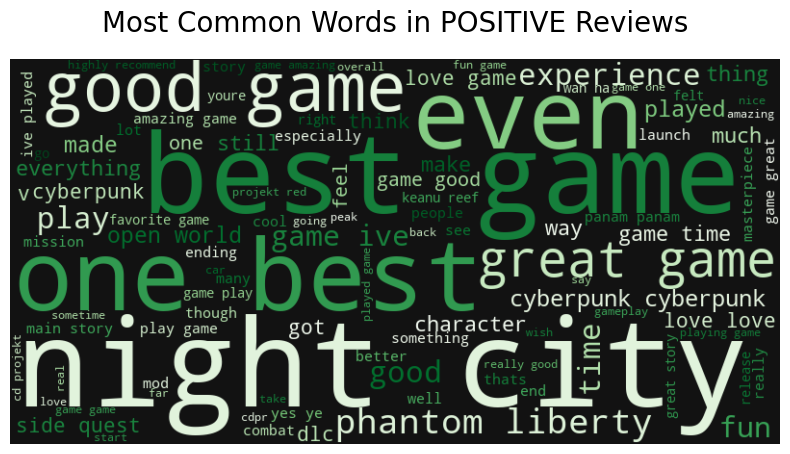

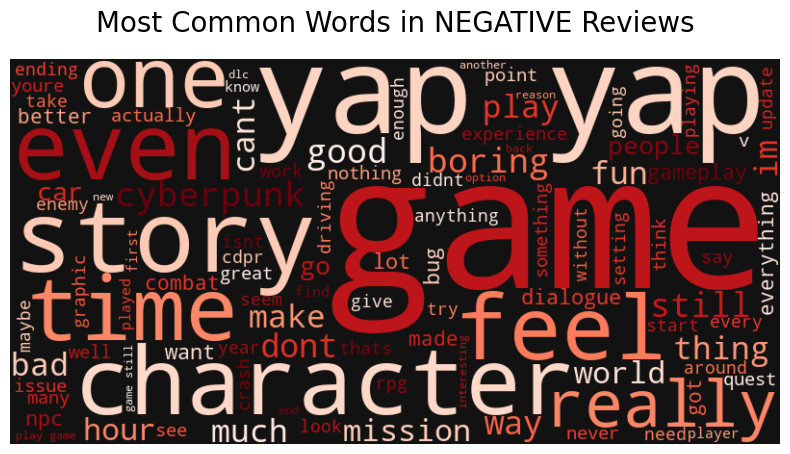

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate the positive and negative reviews based on our label
positive_reviews = df[df['voted_up'] == True]['clean_text'].dropna()
negative_reviews = df[df['voted_up'] == False]['clean_text'].dropna()

# Combine all the text into two giant strings
positive_text = ' '.join(positive_reviews)
negative_text = ' '.join(negative_reviews)

# Function to generate and display a word cloud
def plot_wordcloud(text, title, colormap):
    wordcloud = WordCloud(width=800, height=400, background_color='#121212', colormap=colormap, max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20, color='black', pad=20)
    plt.show()

# Method 6: Word Frequency Analysis (Visualized)
print("Generating Word Clouds...")
plot_wordcloud(positive_text, "Most Common Words in POSITIVE Reviews", 'Greens')
plot_wordcloud(negative_text, "Most Common Words in NEGATIVE Reviews", 'Reds')

N-Grams Analysis


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/aryanjadhav2033/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/aryanjadhav2033/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


--- N-GRAMS ANALYSIS ---


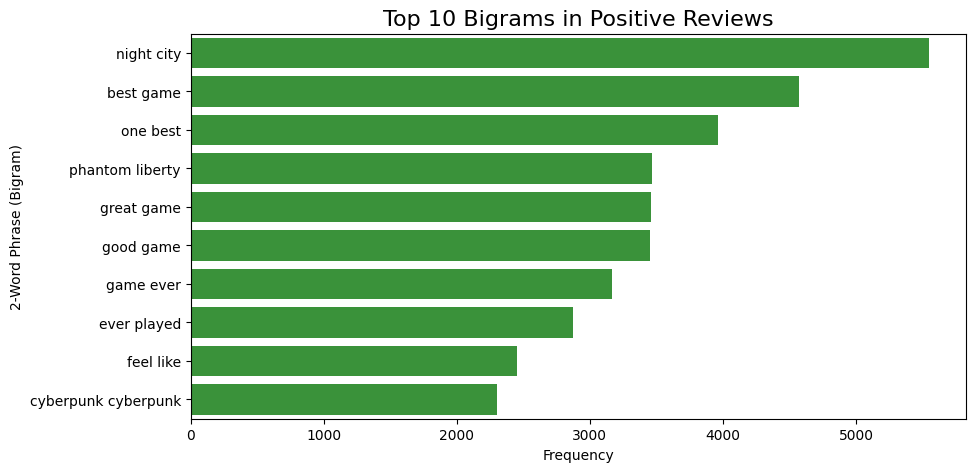

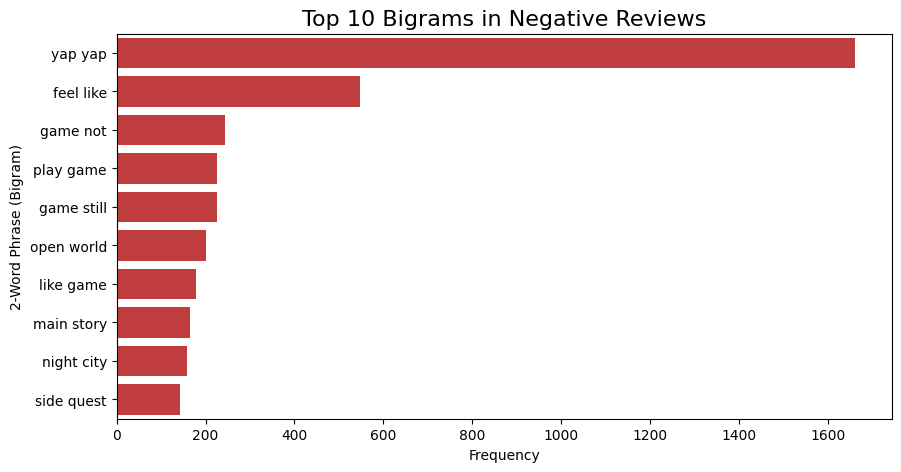

In [35]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import nltk

# Download the POS tagger dictionaries
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


def plot_top_bigrams(text_series, title, color):
    # Use CountVectorizer to find sequences of 2 words (ngram_range=(2,2))
    vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=10)
    bigrams = vectorizer.fit_transform(text_series)
    
    # Calculate frequencies
    sum_words = bigrams.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    # Plotting the bar chart
    x, y = zip(*words_freq)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(y), y=list(x), color=color)
    plt.title(title, fontsize=16)
    plt.xlabel('Frequency')
    plt.ylabel('2-Word Phrase (Bigram)')
    plt.show()

print("--- N-GRAMS ANALYSIS ---")
positive_clean = df[df['voted_up'] == True]['clean_text'].dropna()
negative_clean = df[df['voted_up'] == False]['clean_text'].dropna()

plot_top_bigrams(positive_clean, 'Top 10 Bigrams in Positive Reviews', '#2ca02c')
plot_top_bigrams(negative_clean, 'Top 10 Bigrams in Negative Reviews', '#d62728')




In [36]:

print("--- PART-OF-SPEECH TAGGING DEMONSTRATION ---")
def demonstrate_pos_tagging(text):
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    print(f"Original Text: '{text}'")
    print("POS Tags (NN=Noun, JJ=Adjective, VB=Verb, RB=Adverb):")
    print(pos_tags)

# Show the professor that we can identify grammatical structures
sample_review = "The graphics are amazingly beautiful but the game constantly crashes."
demonstrate_pos_tagging(sample_review)

--- PART-OF-SPEECH TAGGING DEMONSTRATION ---
Original Text: 'The graphics are amazingly beautiful but the game constantly crashes.'
POS Tags (NN=Noun, JJ=Adjective, VB=Verb, RB=Adverb):
[('The', 'DT'), ('graphics', 'NNS'), ('are', 'VBP'), ('amazingly', 'RB'), ('beautiful', 'JJ'), ('but', 'CC'), ('the', 'DT'), ('game', 'NN'), ('constantly', 'RB'), ('crashes', 'NNS'), ('.', '.')]


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

TF-IDF Text Vectorization

In [38]:
# Ensure no empty rows sneak in
df = df.dropna(subset=['clean_text'])
# X is our Text (Features), y is our Labels (Target: True/False)
X = df['clean_text']
y = df['voted_up'].astype(int) # Convert True/False into 1/0 for the math model

print("Converting text to numbers using TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000) # We keep the top 5000 most important words
X_vectorized = vectorizer.fit_transform(X)
# Split the data: 80% to train the AI, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

Converting text to numbers using TF-IDF...


Supervised Machine Learning (Logistic Regression)

In [39]:
print("Training the Machine Learning Model...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Ask the AI to predict the sentiment of the 20% testing data
y_pred = model.predict(X_test)

Training the Machine Learning Model...


/Users/aryanjadhav2033/Downloads/NLP 2/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/aryanjadhav2033/Downloads/NLP 2/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/aryanjadhav2033/Downloads/NLP 2/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


Model Evaluation


⭐ MODEL ACCURACY: 96.46% ⭐

Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.82      0.40      0.54       953
Positive (1)       0.97      1.00      0.98     17485

    accuracy                           0.96     18438
   macro avg       0.90      0.70      0.76     18438
weighted avg       0.96      0.96      0.96     18438



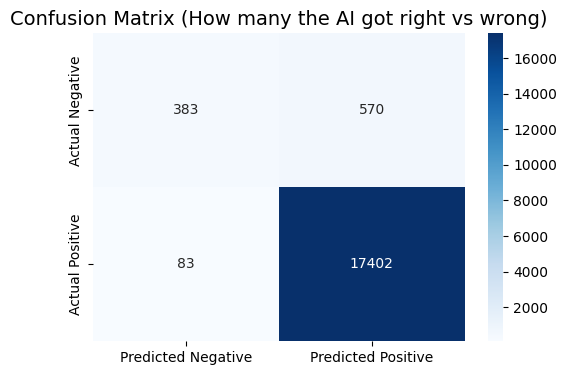

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n⭐ MODEL ACCURACY: {accuracy * 100:.2f}% ⭐\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative (0)", "Positive (1)"]))
# Visualizing the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Predicted Negative", "Predicted Positive"], 
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix (How many the AI got right vs wrong)", fontsize=14)
plt.show()

Topic Modeling (Latent Dirichlet Allocation - LDA)

In [41]:
from sklearn.decomposition import LatentDirichletAllocation

In [42]:
print("Discovering Hidden Topics in the Reviews using LDA...")
# We use the TF-IDF vectorizer from Method 9, and ask LDA to find 3 distinct topics
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(X_train) # Training the topic model
# A quick function to print out the top words in each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"⭐ Topic {topic_idx + 1}:")
        # Find the most heavily weighted words for this specific topic
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(" | ".join(top_words))
        print("-" * 50)
# Get the actual English words back out of our TF-IDF math matrix
tf_feature_names = vectorizer.get_feature_names_out()
print("\n--- TOP 3 THEMES DISCOVERED BY THE AI ---")
display_topics(lda_model, tf_feature_names, 10)

Discovering Hidden Topics in the Reviews using LDA...

--- TOP 3 THEMES DISCOVERED BY THE AI ---
⭐ Topic 1:
game | fun | amazing | story | not | play | like | world | time | still
--------------------------------------------------
⭐ Topic 2:
good | peak | game | like | choom | absolute | nan | pretty | preem | cinema
--------------------------------------------------
⭐ Topic 3:
game | great | best | ever | love | yes | one | played | awesome | cool
--------------------------------------------------


Time-Series Graph

Generating Time-Series Sentiment Graph...


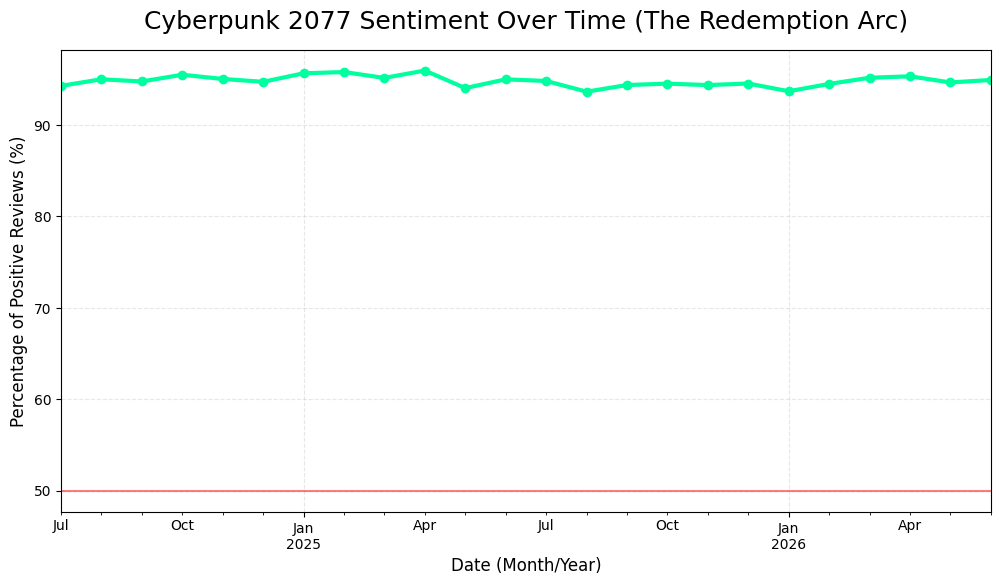

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

print("Generating Time-Series Sentiment Graph...")

# Convert the raw timestamp to a readable Date format
df['date'] = pd.to_datetime(df['timestamp_created'], unit='s')
df['month_year'] = df['date'].dt.to_period('M')

# Calculate the percentage of Positive reviews per month
monthly_sentiment = df.groupby('month_year')['voted_up'].mean() * 100

# Plotting the "Redemption Arc"
plt.figure(figsize=(12, 6))
monthly_sentiment.plot(kind='line', color='#00ff9f', marker='o', linewidth=3)
# Formatting the graph to look like a premium data science report
plt.style.use('dark_background')
plt.title('Cyberpunk 2077 Sentiment Over Time (The Redemption Arc)', fontsize=18, pad=15)
plt.ylabel('Percentage of Positive Reviews (%)', fontsize=12)
plt.xlabel('Date (Month/Year)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.axhline(y=50, color='red', linestyle='-', alpha=0.5) # The 50% baseline
plt.show()

Named Entity Recognition

In [49]:
import spacy
import spacy.cli

# Force the download inside the notebook
spacy.cli.download("en_core_web_sm")

# Load the English NLP model
nlp = spacy.load("en_core_web_sm")

print("--- NAMED ENTITY RECOGNITION (NER) ---")
print("Scanning reviews in batches to protect computer memory...\n")

# Let's process 20,000 reviews. (You can increase this, but it will take longer!)
reviews_list = df['clean_text'].dropna().head(20000).tolist()

entities = {}

# nlp.pipe() acts like a factory assembly line, processing 100 reviews at a time
for doc in nlp.pipe(reviews_list, batch_size=100):
    for ent in doc.ents:
        if ent.label_ in ['PERSON', 'ORG', 'GPE']:
            if ent.text not in entities:
                entities[ent.text] = 1
            else:
                entities[ent.text] += 1

# Sort and print the top 20 most mentioned names/locations
sorted_entities = sorted(entities.items(), key=lambda x: x[1], reverse=True)[:20]

print("Top Characters & Entities mentioned in the reviews:")
for name, count in sorted_entities:
    if len(name) > 2: # Filter out weird 1-2 letter text artifacts
        print(f" - {name.capitalize()} (Mentioned {count} times)")

You should consider upgrading via the '/Users/aryanjadhav2033/Downloads/NLP 2/.venv/bin/python -m pip install --upgrade pip' command.


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
--- NAMED ENTITY RECOGNITION (NER) ---
Scanning reviews in batches to protect computer memory...

Top Characters & Entities mentioned in the reviews:
 - Johnny (Mentioned 291 times)
 - Devs (Mentioned 137 times)
 - Nan (Mentioned 112 times)
 - Max (Mentioned 100 times)
 - Xbox (Mentioned 57 times)
 - Keanu (Mentioned 56 times)
 - Judy (Mentioned 47 times)
 - Nasa (Mentioned 44 times)
 - Kinda (Mentioned 42 times)
 - Ark (Mentioned 37 times)
 - Merc (Mentioned 37 times)
 - Katana (Mentioned 35 times)
 - Nomad (Mentioned 34 times)
 - Gpu (Mentioned 32 times)
 - Johnny silverhand (Mentioned 30 times)
 - Idris elba (Mentioned 26 times)
 - Jackie (Mentioned 25 

In [50]:
# Split all the cleaned text by spaces and count the total number of words
total_tokens = df['clean_text'].dropna().apply(lambda x: len(x.split())).sum()

print(f"Total tokens (words) in the dataset: {total_tokens:,}")

Total tokens (words) in the dataset: 1,723,959
